In [ ]:
# Training and fine-tuning the model.


# Phase 1: Environment Setup and Data Preparation
# ------------------------------------------------
# The initial stage focuses on preparing the computing environment and the dataset for training
#  - Data Acquisition:
#    Google Drive is mounted to access a pre-partitioned dataset (Train, Validation, and Test sets)
#    stored as a zip file.
#  - Pipeline Configuration:
#    Images are loaded with a target size of 224x224 and a batch size of 32.
#  - Data Augmentation:
#    To improve model robustness against real-world variables
#    like lighting and camera angles, the pipeline includes random flips, rotations, zooms,
#    and contrast adjustments.


# Phase 2: Feature Extraction (Transfer Learning)
# ------------------------------------------------
# In this phase, the core architecture is established using Transfer Learning:
#  - Base Model:
#    A ResNet50 model pre-trained on ImageNet is loaded with its top layers removed.
#  - Freezing: The weights of the ResNet50 base are frozen, and a custom head
#    (Global Average Pooling, Dense layer of 512 units, and Dropout) is added.
#  - Initial Training:
#    Training only these custom layers for 5 epochs resulted in a validation
#    accuracy of approximately 95.29%.

# Phase 3: Hyperparameter Optimization
# -------------------------------------
#To maximize performance, a systematic search for the best model configuration was performed:
#  - Keras Tuner:
#    RandomSearch was used to test 10 different combinations of variables.
#  - Search Space:
#    The tuner evaluated different dense units (128–512),
#    dropout rates (0.2–0.5), and learning rates.
#  - Fine-Tuning Depth:
#    Crucially, it tested how many layers of the ResNet50 base to
#    "unfreeze" (between 10 and 50 layers) for deep fine-tuning.

# Phase 4: Final Fine-Tuning and Evaluation
#-------------------------------------------
# The final phase involves training the optimized model and verifying its accuracy:
#  -  Optimized Parameters:
#     The best results were found using 128 dense units, a 0.4 dropout rate,
#     and unfreezing the top 40 layers of the base model.
#  -  Performance:
#     After 10 epochs of fine-tuning, the validation accuracy stabilized at 99.30%.
#   - Final Result:
#     The model achieved a final Test Accuracy of 99.22%, and the resulting model
#     file (resnet_leaf_finetuned_b1.keras) was saved to Google Drive.

# Summary
# Please see the bottom of this notebook

In [ ]:
# Loading Google Drive to read zip file.
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
# Copying the zipfile of the processed images to Colab
!cp /content/gdrive/MyDrive/leaf_diagnosis_project/data/plantVillage_split_processed.zip /content/

In [ ]:
# Unzipping the data in Colab disk
!unzip -q /content/plantVillage_split_processed.zip -d /content/data


In [ ]:
# Sanity check that data exists on Colab disk
!ls /content/data/plantVillage_split_processed

test  train  val


In [ ]:
# Setting up directory paths
base_dir = "/content/data/plantVillage_split_processed"
train_dir = base_dir + "/train"
val_dir   = base_dir + "/val"
test_dir  = base_dir + "/test"

In [ ]:
# Install Keras Tuner
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.7 MB/s eta 0:00:00


In [ ]:
# Import libraries for Deep Learning and Transfer Learning using ResNet50

import os
import json
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.utils import plot_model

In [ ]:
# Set batch size and image dimensions, then create TensorFlow datasets from directories
# shuffle=False for test_ds to ensure consistent evaluation
# Data Loading Pipeline:
# - Batch Size: 32 | Image Size: 224x224
# - Loads pre-partitioned plant disease images into tf.data.Dataset objects

BATCH_SIZE = 32
IMG_SIZE = (224, 224)


train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 37997 files belonging to 38 classes.
Found 8129 files belonging to 38 classes.
Found 8179 files belonging to 38 classes.


In [ ]:
# Extract class names from the dataset and determine the total number of classes

class_names = train_ds.class_names
num_classes = len(class_names)

In [ ]:
# Optimize data pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Classes:", num_classes)
print(class_names[:10])

Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


In [ ]:
# Sanity check
!ls /content/data/plantVillage_split_processed/

test  train  val


In [ ]:
# Save class indices locally

with open("/content/leaf_class_indices.json", "w") as f:
    json.dump(class_names, f)

print("Class indices saved locally !")

Class indices saved locally !


In [ ]:
# Save class indices to Google Drive
os.makedirs("/content/gdrive/MyDrive/leaf_diagnosis_project/models", exist_ok=True)
drive_path = "/content/gdrive/MyDrive/leaf_diagnosis_project/models/leaf_class_indices_b1.json"

# Save to Drive
with open(drive_path, "w") as f:
    json.dump(class_names, f)

print("Class indices saved to Google Drive!")

Class indices saved to Google Drive!


In [ ]:
# Data Augmentation.
# This is necessary since real images have natural lighting, cluttered backgrounds,
# different leaf positions different camera angles

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

In [ ]:
# Build feature extraction model

# Load pre-trained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# Define the augmentation stage to apply augmentation during training
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)   # fixed bug: use x, not inputs
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

feature_model = tf.keras.Model(inputs, outputs)

feature_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

feature_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 38)        │     19,494 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,656,294 (94.06 MB)

 Trainable params: 1,068,582 (4.08 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Save model architecture image

os.makedirs("/content/gdrive/MyDrive/leaf_diagnosis_project/images", exist_ok=True)

plot_model(
    feature_model,
    show_shapes=True,
    show_layer_names=True,
    to_file="/content/gdrive/MyDrive/leaf_diagnosis_project/images/model_architecture_b1.png"
)

print("Architecture image saved.")

Architecture image saved.


In [ ]:
# Callbacks
# Setting valiation accuracy = 3
# Watching Validation Loss

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

In [ ]:
# Train feature extraction phase

EPOCHS_FE = 5

history_fe = feature_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FE,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.8606 - loss: 0.4587 - val_accuracy: 0.9114 - val_loss: 0.2560 - learning_rate: 0.0010
Epoch 2/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 37s 32ms/step - accuracy: 0.9227 - loss: 0.2376 - val_accuracy: 0.9157 - val_loss: 0.2576 - learning_rate: 0.0010
Epoch 3/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - accuracy: 0.9334 - loss: 0.1997 - val_accuracy: 0.9168 - val_loss: 0.2757 - learning_rate: 0.0010
Epoch 4/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - accuracy: 0.9623 - loss: 0.1100 - val_accuracy: 0.9481 - val_loss: 0.1581 - learning_rate: 2.0000e-04
Epoch 5/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - accuracy: 0.9648 - loss: 0.1014 - val_accuracy: 0.9529 - val_loss: 0.1467 - learning_rate: 2.0000e-04


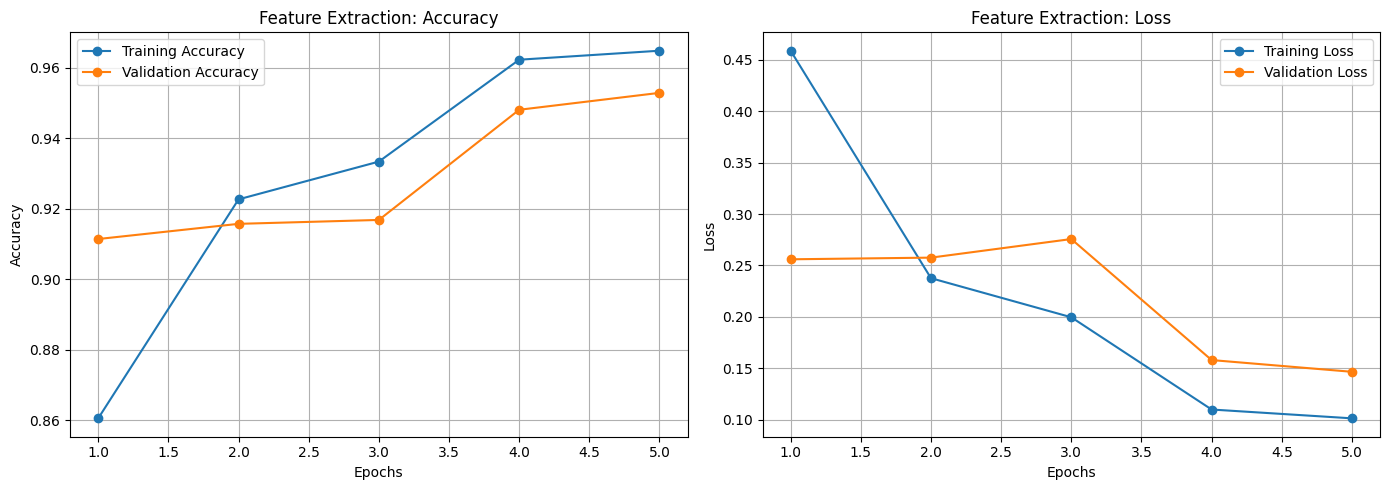

In [ ]:
# Plotting feature extraction results

acc = history_fe.history["accuracy"]
val_acc = history_fe.history["val_accuracy"]
loss = history_fe.history["loss"]
val_loss = history_fe.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy", marker="o")
plt.plot(epochs_range, val_acc, label="Validation Accuracy", marker="o")
plt.title("Feature Extraction: Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss", marker="o")
plt.plot(epochs_range, val_loss, label="Validation Loss", marker="o")
plt.title("Feature Extraction: Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/leaf_diagnosis_project/images/feature_extraction_curves_b1.jpg", bbox_inches="tight")
plt.show()

In [ ]:
# Save feature extraction model

feature_model_path = "/content/gdrive/MyDrive/leaf_diagnosis_project/models/resnet_leaf_feature_extractor_b1.keras"
feature_model.save(feature_model_path)
print("Feature extraction model saved.")

Feature extraction model saved.


In [ ]:
# Hypermodel for Keras Tuner
# dense_units: Choosing between 128, 256, or 512 for the final fully connected layer
# dropout_rate: Testing values from 0.2 to 0.5 to find the best balance against overfitting.
# learning_rate: Testing four different speeds for the Adam optimizer
# unfreeze_layers: Testing how deep the fine-tuning should go by unfreezing
# between 10 and 50 layers of the ResNet50 base.

def build_finetune_model(hp):
    dense_units = hp.Choice("dense_units", values=[128, 256, 512])
    dropout_rate = hp.Float("dropout_rate", min_value=0.2, max_value=0.5, step=0.1)
    learning_rate = hp.Choice("learning_rate", values=[1e-5, 3e-5, 1e-4, 3e-4])
    unfreeze_layers = hp.Choice("unfreeze_layers", values=[10, 20, 30, 40, 50])

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = True

    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# Initializiing HyperParameter Tuner

# Using RandomSearch to pick combinations of hyperparameters defined in the build function.
# It is often more efficient than GridSearch for finding a "good enough" model quickly.

tuner = kt.RandomSearch(
    hypermodel=build_finetune_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    directory="/content/keras_tuner",
    project_name="resnet50_leaf_finetune"
)

tuner.search_space_summary()


Search space summary
Default search space size: 4
dense_units (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
dropout_rate (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 1e-05, 'conditions': [], 'values': [1e-05, 3e-05, 0.0001, 0.0003], 'ordered': True}
unfreeze_layers (Choice)
{'default': 10, 'conditions': [], 'values': [10, 20, 30, 40, 50], 'ordered': True}


In [ ]:
# Run hyperparameter search
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[early_stop, reduce_lr]
)

Trial 10 Complete [00h 06m 37s]
val_accuracy: 0.9848690032958984

Best val_accuracy So Far: 0.9917579293251038
Total elapsed time: 01h 09m 38s


In [ ]:
# Show best hyperparameters

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best dense_units:", best_hp.get("dense_units"))
print("Best dropout_rate:", best_hp.get("dropout_rate"))
print("Best learning_rate:", best_hp.get("learning_rate"))
print("Best unfreeze_layers:", best_hp.get("unfreeze_layers"))

Best dense_units: 128
Best dropout_rate: 0.4
Best learning_rate: 0.0001
Best unfreeze_layers: 40


In [ ]:
# Build best tuned model

best_model = tuner.hypermodel.build(best_hp)
best_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 38)        │      4,902 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,854,886 (91.00 MB)

 Trainable params: 16,098,982 (61.41 MB)

 Non-trainable params: 7,755,904 (29.59 MB)

In [ ]:
# Train best tuned model

EPOCHS_BEST = 10

history_best = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BEST,
    callbacks=[early_stop, reduce_lr]
)



Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 71s 49ms/step - accuracy: 0.8759 - loss: 0.4610 - val_accuracy: 0.9621 - val_loss: 0.1231 - learning_rate: 1.0000e-04
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 55s 47ms/step - accuracy: 0.9610 - loss: 0.1330 - val_accuracy: 0.9697 - val_loss: 0.1059 - learning_rate: 1.0000e-04
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 55s 47ms/step - accuracy: 0.9707 - loss: 0.0976 - val_accuracy: 0.9590 - val_loss: 0.1424 - learning_rate: 1.0000e-04
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 55s 47ms/step - accuracy: 0.9767 - loss: 0.0775 - val_accuracy: 0.9792 - val_loss: 0.0695 - learning_rate: 1.0000e-04
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 55s 47ms/step - accuracy: 0.9806 - loss: 0.0645 - val_accuracy: 0.9855 - val_loss: 0.0445 - learning_rate: 1.0000e-04
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - accuracy: 0.9821 - loss: 0.0586 - val_accuracy: 0.9781 - val_loss: 0.0730 - learning_rate: 1.0000e-04
Epoch 7/10
1188/1188 ━━━━━━━━━━━━━━━━━━━

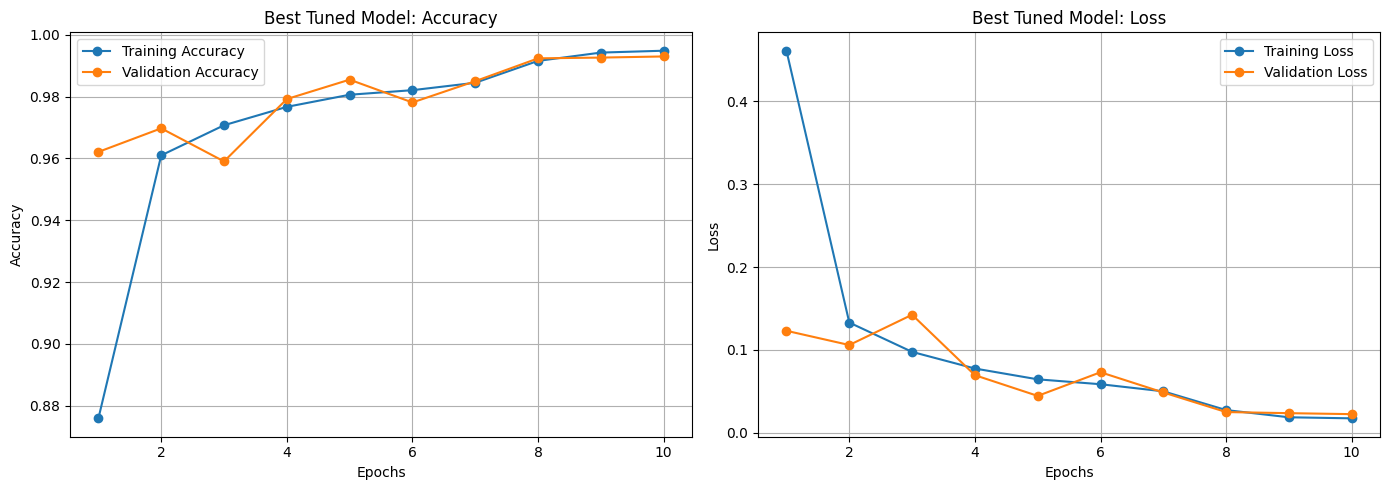

In [ ]:
# Plot tuned model results

best_acc = history_best.history["accuracy"]
best_val_acc = history_best.history["val_accuracy"]
best_loss = history_best.history["loss"]
best_val_loss = history_best.history["val_loss"]

epochs_best_range = range(1, len(best_acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_best_range, best_acc, label="Training Accuracy", marker="o")
plt.plot(epochs_best_range, best_val_acc, label="Validation Accuracy", marker="o")
plt.title("Best Tuned Model: Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_best_range, best_loss, label="Training Loss", marker="o")
plt.plot(epochs_best_range, best_val_loss, label="Validation Loss", marker="o")
plt.title("Best Tuned Model: Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/leaf_diagnosis_project/images/best_tuned_curves_b1.jpg", bbox_inches="tight")
plt.show()



In [ ]:
# Save final tuned model

final_model_path = "/content/gdrive/MyDrive/leaf_diagnosis_project/models/resnet_leaf_finetuned_b1.keras"
best_model.save(final_model_path)
print("Final tuned model saved.")


Final tuned model saved.


In [ ]:
# Evaluate on test set

test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Best Tuned Model Test Accuracy: {test_acc * 100:.2f}%")


256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9922 - loss: 0.0272
Best Tuned Model Test Accuracy: 99.22%


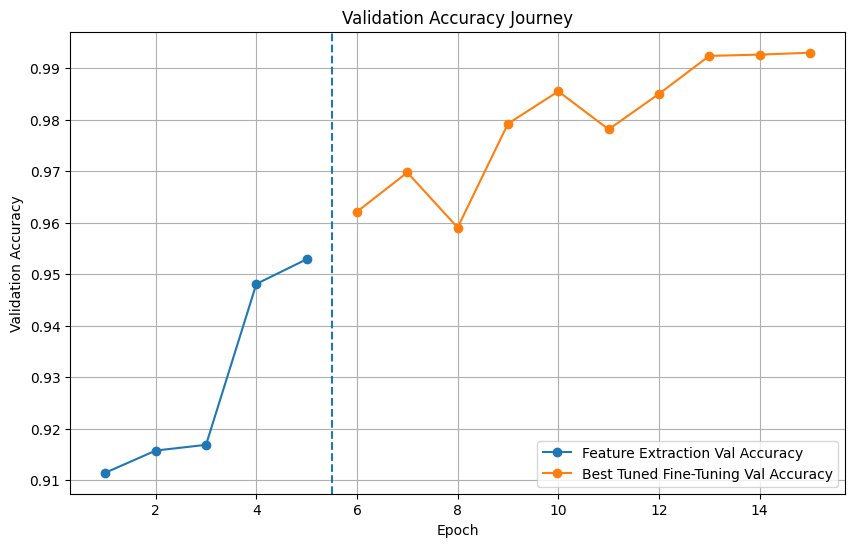

In [ ]:
# compare feature extraction vs tuned model

fe_val_acc = history_fe.history["val_accuracy"]
best_val_acc = history_best.history["val_accuracy"]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(fe_val_acc) + 1), fe_val_acc, marker="o", label="Feature Extraction Val Accuracy")
plt.plot(
    range(len(fe_val_acc) + 1, len(fe_val_acc) + len(best_val_acc) + 1),
    best_val_acc,
    marker="o",
    label="Best Tuned Fine-Tuning Val Accuracy"
)

plt.axvline(x=len(fe_val_acc) + 0.5, linestyle="--")
plt.title("Validation Accuracy Journey")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("/content/gdrive/MyDrive/leaf_diagnosis_project/images/fe_vs_tuned_accuracy_b1.jpg", bbox_inches="tight")
plt.show()

In [ ]:
# Summary

# Initial Feature Extraction:
#    By training only the custom classification head for 5 epochs, the model
#    reached a validation accuracy of 95.29%.
# Hyperparameter Search:
#    Out of 10 experimental trials using Keras Tuner, the optimal configuration
#    was identified:
#    - Dense Units: 128
#    - Dropout Rate: 0.4
#    - Fine-tuning Depth: Unfreezing the top 40 layers of ResNet50.
# Peak Validation Performance:
#    After 10 epochs of fine-tuning with the optimized parameters,
#    validation accuracy peaked at 99.30%.
# Final Test Accuracy:
#    The model demonstrated exceptional generalization on unseen data
#    with a final test accuracy of 99.22% and a loss of 0.0272.